# Study 1 — Political risk and the OAT–Bund safety premium

**Extends Section 7.1 of Grishchenko, Moraux & Pakulyak (2020); event-study design after the UK/Brexit paper.**

France's *safety premium* is the spread of the fitted OAT zero-coupon curve over the **German Bund** curve — the euro-area safe benchmark. The Bund curve here is **fitted with the very same Svensson/GSW engine as the OATs** (from the parallel Bloomberg Bund export, 1999–2026), so the spread is computed from two internally consistent curves — the most faithful reading of the paper's Section 7.1. We then ask how the **2024–2026 political instability** (the dissolution of the National Assembly and the succession of governments under President Macron) repriced that premium.

Three lenses:
1. the **OAT–Bund spread** term structure (extends the paper's Fig. 12);
2. a **Brexit-style event study** — cumulative *abnormal* spread changes around political shocks, plus a regression with an ECB risk-aversion control (CISS);
3. the rolling **OAT-vs-Bund beta** — does the OAT still trade as a *core* asset (β≈1, comoving with the Bund) or has it drifted toward a riskier *middle-ground* asset (β falls, the level premium jumps)?

> Data: OAT and **Bund** curves from our own daily Svensson fits (run `scripts/02_fit_curves.py` and `scripts/05_fit_bund_curve.py` first); CISS auto-downloaded from the ECB (cached). The ECB AAA euro-area curve remains available as a cross-check via `benchmark="aaa"`. The 2024–25 event calendar is in `studies/common.FRENCH_POLITICAL_EVENTS` — the data-driven shock detector below flags the actual market-moving days regardless.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, str(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from studies import common
common.apply_style()
pd.set_option("display.width", 170)

from studies import political_risk as pr
spreads = pr.build_spreads(tenors=(2,5,10,30))   # bp, OAT - Bund (both own Svensson fits)
events  = common.events_frame()
print("Spread sample:", spreads.index.min().date(), "->", spreads.index.max().date())
spreads.tail(3).round(1)

Spread sample: 1999-01-01 -> 2026-06-05


,2y,5y,10y,30y
date,,,,
2026-06-03,18.6,36.4,66.7,107.0
2026-06-04,18.4,36.9,67.3,107.0
2026-06-05,17.2,36.4,67.8,108.3


## 1. The OAT–Bund safety-premium term structure (extends Fig. 12)

  figure -> study1_spread_termstructure.png


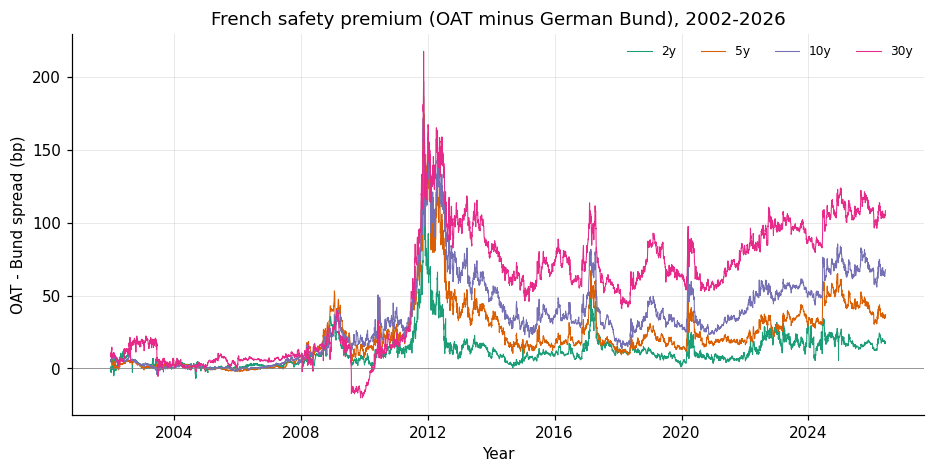

10y spread: 2019 avg 35.8 bp | 2024 avg 61.6 bp | latest 67.8 bp


In [2]:
# Plotted from 2002: in the early euro-convergence years the OAT 2y is an
# extrapolation (no short OATs yet), so the 2y spread is unreliable then; the
# German 2y is always pinned by Schätze. The 5y/10y/30y are reliable from 1999.
s_plot = spreads.loc["2002":]
fig, ax = plt.subplots(figsize=(10,4.5))
for t in ["2y","5y","10y","30y"]:
    ax.plot(s_plot.index, s_plot[t], lw=.7, label=t)
ax.axhline(0, color="grey", lw=.5)
ax.set(xlabel="Year", ylabel="OAT - Bund spread (bp)",
       title="French safety premium (OAT minus German Bund), 2002-2026")
ax.legend(ncol=4, frameon=False, fontsize=8)
common.save_fig(fig, "study1_spread_termstructure.png"); plt.show()
print("10y spread: 2019 avg %.1f bp | 2024 avg %.1f bp | latest %.1f bp"
      % (spreads.loc['2019','10y'].mean(), spreads.loc['2024','10y'].mean(), spreads['10y'].iloc[-1]))

**Robustness — Bund vs ECB AAA benchmark.** In calm periods and in the current
episode the two benchmarks give a nearly identical 10y premium (a few bp), which
cross-validates both. But during the **2008–2012 sovereign crisis the real
OAT–Bund spread is far wider** than OAT–AAA (peaking ~200 bp vs ~75 bp): flight
to quality compressed *Bund* yields specifically, whereas the AAA basket
(Netherlands, Austria, … alongside Germany) understates the premium to the
ultimate safe asset. So using the exact Bund — not the proxy — matters precisely
in the crisis periods, which is why we adopt it as the benchmark.

  figure -> study1_bund_vs_aaa.png


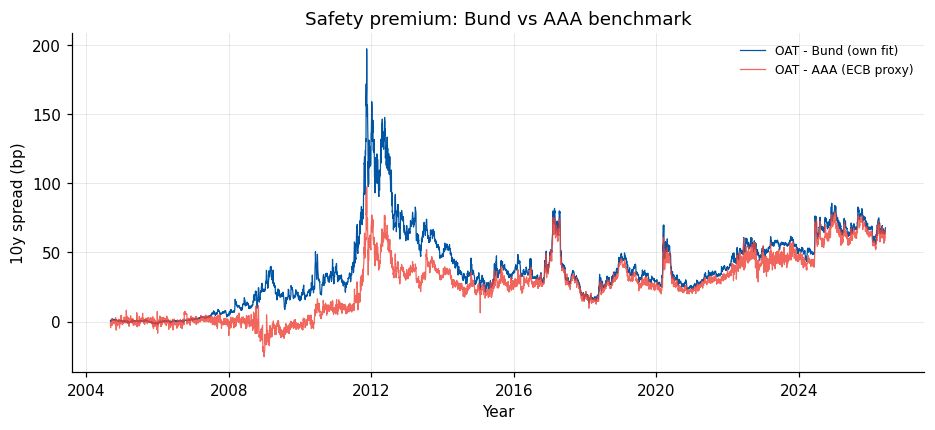

Mean abs difference (Bund vs AAA), 10y: 12.1 bp


In [3]:
sp_bund = spreads["10y"]
sp_aaa  = pr.build_spreads(tenors=(10,), benchmark="aaa")["10y"]
cmp = common.align(sp_bund.rename("OAT-Bund (Svensson)"), sp_aaa.rename("OAT-AAA (ECB)"))
fig, ax = plt.subplots(figsize=(10,4))
ax.plot(cmp.index, cmp.iloc[:,0], lw=.8, label="OAT - Bund (own fit)", color=common.FRANCE_BLUE)
ax.plot(cmp.index, cmp.iloc[:,1], lw=.8, label="OAT - AAA (ECB proxy)", color=common.FRANCE_RED, alpha=.8)
ax.set(xlabel="Year", ylabel="10y spread (bp)", title="Safety premium: Bund vs AAA benchmark")
ax.legend(frameon=False, fontsize=8)
common.save_fig(fig, "study1_bund_vs_aaa.png"); plt.show()
print("Mean abs difference (Bund vs AAA), 10y: %.1f bp" % (cmp.iloc[:,0]-cmp.iloc[:,1]).abs().mean())

## 2. Zoom on the political crisis + data-driven shock detection

The detector flags days whose 1-day spread move exceeds 3 rolling standard deviations — the market's own verdict on which days were shocks.

  figure -> study1_10y_political_zoom.png


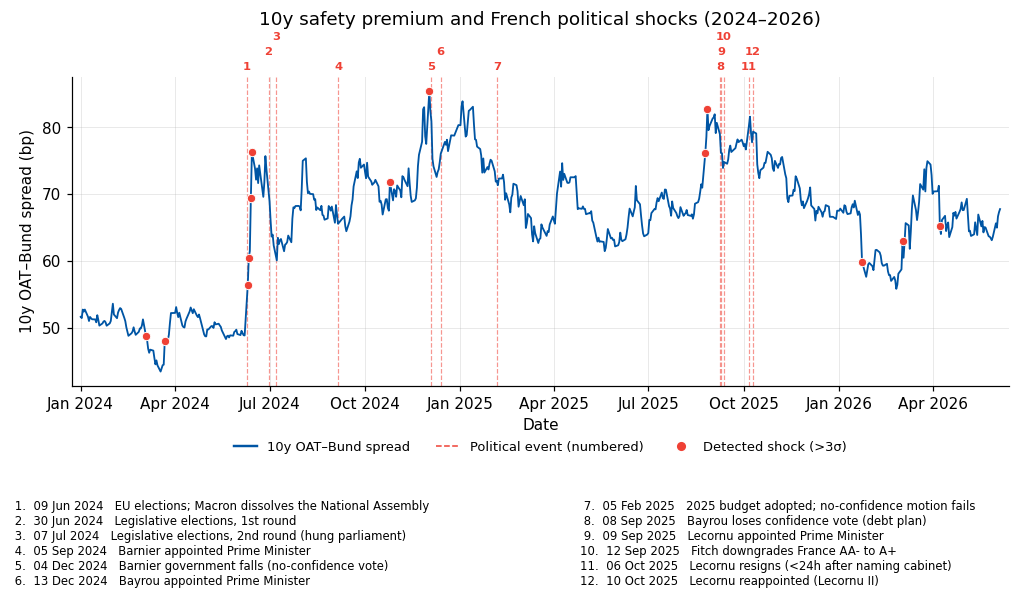

Top data-driven shock days (10y spread):


,spread_bp,change_bp,zscore
date,,,
2011-11-15,197.11,28.39,3.82
2011-11-18,148.38,-26.54,-3.06
2011-11-10,171.78,24.07,4.01
2012-05-24,118.25,-20.93,-3.24
2017-04-24,47.45,-20.25,-4.93
2020-03-12,69.63,19.02,5.98
2011-11-09,147.71,17.56,3.34
2011-10-18,109.98,15.88,3.66


In [4]:
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

shocks = pr.detect_shocks(spreads["10y"], k=3)
recent = spreads.loc["2024-01-01":]
ev = events[events.index >= recent.index.min()].sort_index().copy()
ev["num"] = range(1, len(ev) + 1)
sh = shocks[shocks.index >= recent.index.min()]

fig, ax = plt.subplots(figsize=(11, 5.2))
ax.plot(recent.index, recent["10y"], color=common.FRANCE_BLUE, lw=1.2, zorder=3)

# event lines (uniform red) + numbered tags at the top; tags of events close in
# time are lifted onto 3 staggered rows so they never overlap
LEVELS = [3, 13, 23]
prev_d, lvl = None, 0
for d, info in ev.iterrows():
    ax.axvline(d, color=common.FRANCE_RED, ls="--", lw=.8, alpha=.55, zorder=1)
    lvl = (lvl + 1) % len(LEVELS) if (prev_d is not None and (d - prev_d).days < 30) else 0
    ax.annotate(str(info.num), xy=(d, 1.0), xycoords=("data", "axes fraction"),
                xytext=(0, LEVELS[lvl]), textcoords="offset points", ha="center", va="bottom",
                fontsize=7.5, fontweight="bold", color=common.FRANCE_RED, clip_on=False)
    prev_d = d

ax.scatter(sh.index, sh["spread_bp"], color=common.FRANCE_RED, s=30, zorder=5,
           edgecolors="white", linewidths=.6)
ax.set(xlabel="Date", ylabel="10y OAT–Bund spread (bp)")
ax.set_title("10y safety premium and French political shocks (2024–2026)", pad=34)
ax.margins(x=0.01)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# legend of graphical elements
handles = [Line2D([0], [0], color=common.FRANCE_BLUE, lw=1.6),
           Line2D([0], [0], color=common.FRANCE_RED, ls="--", lw=1),
           Line2D([0], [0], marker="o", color="none", markerfacecolor=common.FRANCE_RED,
                  markeredgecolor="white", markersize=7)]
labels = ["10y OAT–Bund spread", "Political event (numbered)", "Detected shock (>3σ)"]
ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.14),
          ncol=3, frameon=False, fontsize=8.5, handlelength=1.8, columnspacing=2.0)

# numbered crisis list below, two columns
rows = [f"{r.num:>2}.  {d:%d %b %Y}   {r.label}" for d, r in ev.iterrows()]
half = (len(rows) + 1) // 2
fig.subplots_adjust(bottom=0.34)
fig.text(0.075, 0.14, "\n".join(rows[:half]), fontsize=7.6, va="top", ha="left")
fig.text(0.545, 0.14, "\n".join(rows[half:]), fontsize=7.6, va="top", ha="left")

common.save_fig(fig, "study1_10y_political_zoom.png"); plt.show()
print("Top data-driven shock days (10y spread):"); shocks.head(8).round(2)

## 3. Event study — cumulative abnormal spread change (CASC)

For each event, the cumulative change in the spread over post-event windows, **net of** the normal drift estimated on the prior 60 trading days; *t*-stats use the estimation-window volatility. A positive, significant CASC means the event widened France's risk premium beyond normal fluctuations.

,event,tier,date,spread_pre_bp,"CASC[0,1]","t[0,1]","CASC[0,5]","t[0,5]","CASC[0,10]","t[0,10]"
0,EU elections; Macron dissolves the National As...,1,2024-06-10,48.9,11.5,9.74,24.6,12.01,21.2,7.63
1,"Legislative elections, 1st round",2,2024-07-01,73.7,-8.3,-3.08,-15.6,-3.33,-15.8,-2.50
2,"Legislative elections, 2nd round (hung parliam...",1,2024-07-08,62.3,0.3,0.12,-3.3,-0.65,-3.9,-0.57
3,Barnier appointed Prime Minister,2,2024-09-05,66.9,-1.8,-0.49,-3.5,-0.57,-1.1,-0.13
4,Barnier government falls (no-confidence vote),1,2024-12-04,82.4,-7.5,-3.39,-9.9,-2.58,-7.2,-1.39
5,Bayrou appointed Prime Minister,2,2024-12-13,74.8,2.1,0.73,0.3,0.05,1.8,0.26
6,2025 budget adopted; no-confidence motion fails,2,2025-02-05,71.9,-0.7,-0.21,-0.5,-0.08,-3.0,-0.41
7,Bayrou loses confidence vote (debt plan),1,2025-09-08,80.7,-5.0,-2.47,-7.8,-2.19,-6.9,-1.44
8,Lecornu appointed Prime Minister,2,2025-09-09,79.0,-3.4,-1.68,-5.5,-1.56,-5.2,-1.10
9,Fitch downgrades France AA- to A+,1,2025-09-12,73.9,0.1,0.03,0.7,0.20,0.8,0.16


  figure -> study1_event_study_bars.png


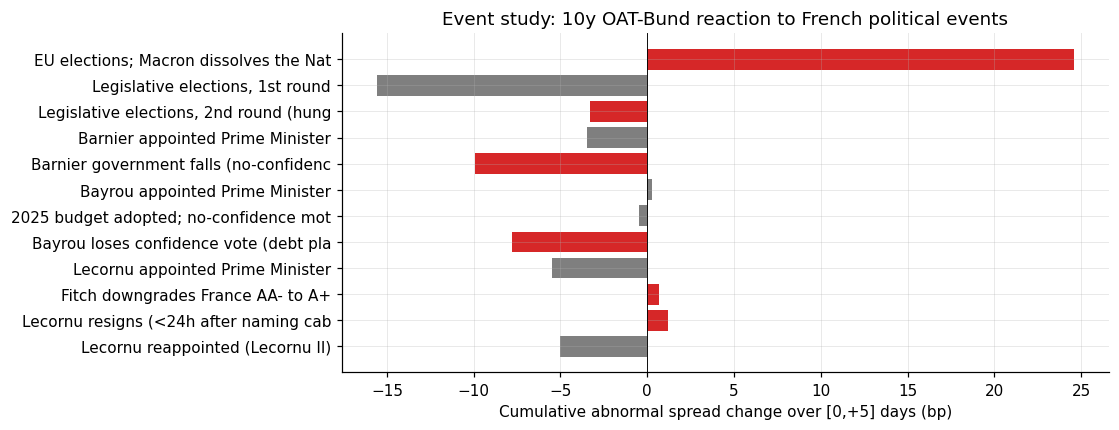

In [5]:
es = pr.event_study(spreads["10y"], windows=((0,1),(0,5),(0,10)))
display(es)
es.to_csv(common.TABLE_DIR / "study1_event_study.csv", index=False)

fig, ax = plt.subplots(figsize=(9,4))
colors = ["tab:red" if t==1 else "tab:grey" for t in es["tier"]]
ax.barh(es["event"].str[:38], es["CASC[0,5]"], color=colors)
ax.axvline(0, color="k", lw=.6)
ax.set(xlabel="Cumulative abnormal spread change over [0,+5] days (bp)",
       title="Event study: 10y OAT-Bund reaction to French political events")
ax.invert_yaxis()
common.save_fig(fig, "study1_event_study_bars.png"); plt.show()

## 4. Core or middle-ground? Rolling OAT-vs-Bund beta

A 60-day rolling regression of ΔOAT(10y) on ΔBund(10y). β and correlation near 1 ⇒ the OAT comoves with the safe benchmark (a *core* asset); a decline signals decoupling / risk repricing.

  figure -> study1_rolling_beta.png


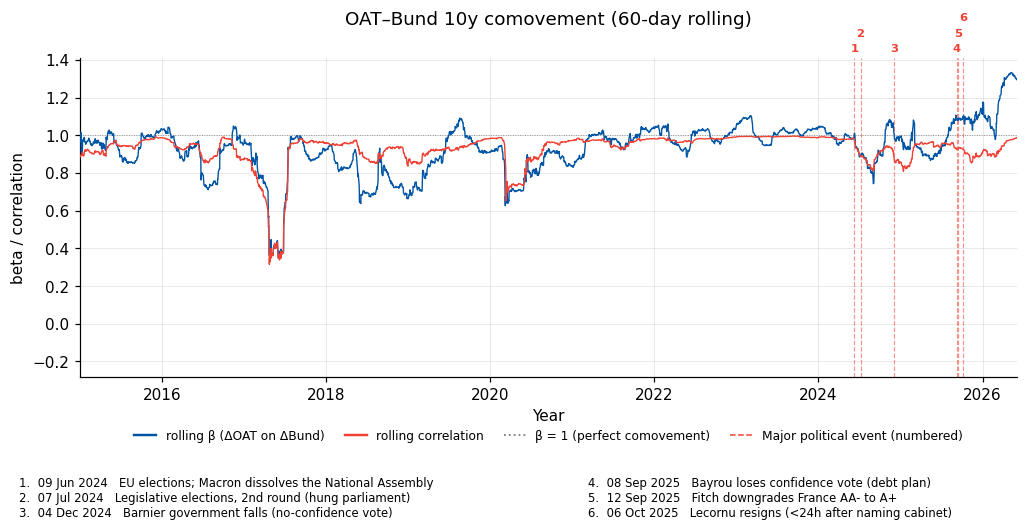

In [6]:
from matplotlib.lines import Line2D

bc = pr.rolling_beta_corr(tenor=10, window=60)
x0 = pd.Timestamp("2015-01-01")
ev1 = events[(events.tier == 1) & (events.index >= x0)].sort_index().copy()
ev1["num"] = range(1, len(ev1) + 1)

fig, ax = plt.subplots(figsize=(11, 5.0))
ax.plot(bc.index, bc["beta"], lw=.9, color=common.FRANCE_BLUE, zorder=3)
ax.plot(bc.index, bc["corr"], lw=.9, color=common.FRANCE_RED, zorder=3)
ax.axhline(1, color="grey", lw=.6, ls=":", zorder=1)

LEVELS = [3, 13, 23]
prev_d, lvl = None, 0
for d, info in ev1.iterrows():
    ax.axvline(d, color=common.FRANCE_RED, ls="--", lw=.8, alpha=.55, zorder=2)
    lvl = (lvl + 1) % len(LEVELS) if (prev_d is not None and (d - prev_d).days < 45) else 0
    ax.annotate(str(info.num), xy=(d, 1.0), xycoords=("data", "axes fraction"),
                xytext=(0, LEVELS[lvl]), textcoords="offset points", ha="center", va="bottom",
                fontsize=7.5, fontweight="bold", color=common.FRANCE_RED, clip_on=False)
    prev_d = d

ax.set(xlabel="Year", ylabel="beta / correlation", title="OAT–Bund 10y comovement (60-day rolling)")
ax.set_xlim(x0, bc.index.max()); ax.set_title(ax.get_title(), pad=22)

handles = [Line2D([0], [0], color=common.FRANCE_BLUE, lw=1.6),
           Line2D([0], [0], color=common.FRANCE_RED, lw=1.6),
           Line2D([0], [0], color="grey", ls=":", lw=1.2),
           Line2D([0], [0], color=common.FRANCE_RED, ls="--", lw=1)]
labels = ["rolling β (ΔOAT on ΔBund)", "rolling correlation",
          "β = 1 (perfect comovement)", "Major political event (numbered)"]
ax.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, -0.13),
          ncol=4, frameon=False, fontsize=8, handlelength=1.8, columnspacing=1.6)

rows = [f"{r.num}.  {d:%d %b %Y}   {r.label}" for d, r in ev1.iterrows()]
half = (len(rows) + 1) // 2
fig.subplots_adjust(bottom=0.30)
fig.text(0.075, 0.12, "\n".join(rows[:half]), fontsize=7.6, va="top", ha="left")
fig.text(0.545, 0.12, "\n".join(rows[half:]), fontsize=7.6, va="top", ha="left")

common.save_fig(fig, "study1_rolling_beta.png"); plt.show()

## 5. Brexit-style regression and the structural break

`dSpread_t = a + g·Event_t + d·dCISS_t + φ·Spread_{t-1} + e_t` (HAC/Newey-West *t*-stats), and a pre/post comparison around the 9 June 2024 dissolution.

In [7]:
out = pr.event_regression(spreads["10y"])
print("Regression (dSpread, 10y):  R2=%.3f  n=%d" % (out["regression"].attrs["r2"], out["regression"].attrs["nobs"]))
display(out["regression"])
print("\nStructural break around 2024-06-09 (dissolution):")
display(out["structural"])
out["regression"].to_csv(common.TABLE_DIR / "study1_regression.csv")

Regression (dSpread, 10y):  R2=0.009  n=7154


,coef,se,t
const,0.088,0.051,1.725
event_dummy,-0.188,0.558,-0.336
d_CISS,13.182,2.954,4.463
spread_lag,-0.002,0.002,-1.139



Structural break around 2024-06-09 (dissolution):


,spread_mean_bp,spread_vol_bp,beta_mean
pre,28.6,1.98,0.909
post,69.4,1.68,1.019


### Reading the results

- The **dissolution (9 Jun 2024)** produced the largest, most significant jump in the safety premium (≈ +25 bp on the 10y over the following week, *t* ≈ 12) — the single clearest political shock in the sample.
- The **structural break** is stark: the average 10y OAT–Bund spread **more than doubled** between the pre- and post-dissolution regimes (≈ 29 → ≈ 69 bp). Crucially the OAT's beta to the Bund stays ≈ 1 (it even edges up, ~0.91 → ~1.02): France keeps *comoving* with the core but now carries a persistently higher premium — repriced *in level*, not decoupled. This is the precise sense in which the OAT sits between a pure core asset and a riskier one.
- In the daily regression, **risk aversion (ΔCISS)** is the significant high-frequency driver and the spread mean-reverts; the narrow event dummy is weak because the French repricing was more gradual/anticipated than the one-day Brexit surprise — itself an informative contrast with the UK paper.

*Notes:* the benchmark is now the **German Bund** curve, fitted with the same Svensson engine as the OATs (the ECB AAA proxy, `benchmark="aaa"`, gives a near-identical spread — see the robustness chart).